# IMPORTING REQUIRED MODULES

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Pipelines
from sklearn.pipeline import Pipeline

# Dimensionality reduction
from sklearn.decomposition import PCA

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score,
    log_loss
)

# Saving models
import joblib

 READING THE DATA FROM THE CSV FILE

In [9]:
data = pd.read_csv("dataset/BEED_Data.csv")

Exploratory data analysis (EDA): 

In [14]:
data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0


In [15]:
data.tail()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
7995,-9,-4,-7,2,-9,-14,-7,12,-5,-3,-2,-2,-12,-5,4,1,3
7996,-8,-4,-7,1,-8,-14,-7,12,-6,-3,-2,-3,-15,-4,4,1,3
7997,-6,-5,-7,1,-8,-14,-7,12,-7,-3,-2,-4,-16,-4,3,1,3
7998,-5,-6,-6,1,-8,-13,-7,13,-7,-2,-3,-5,-15,-4,3,0,3
7999,-4,-7,-5,2,-8,-12,-7,14,-6,0,-3,-6,-13,-4,2,0,3


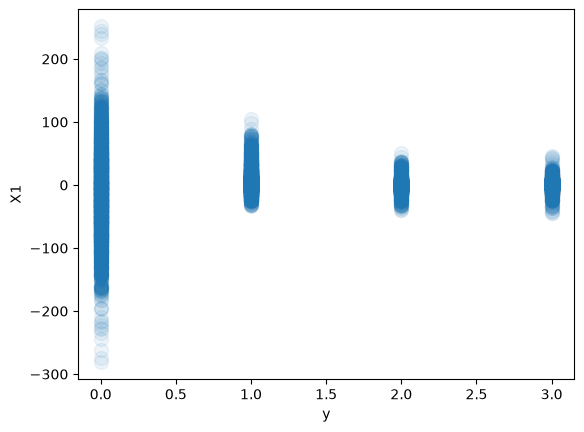

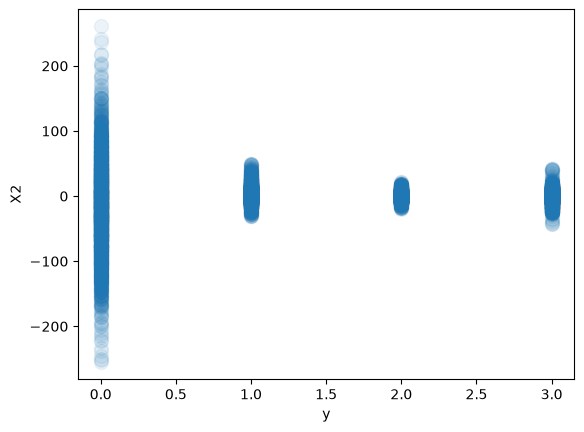

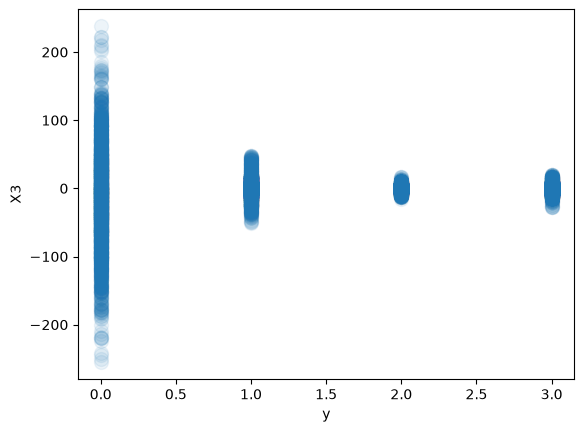

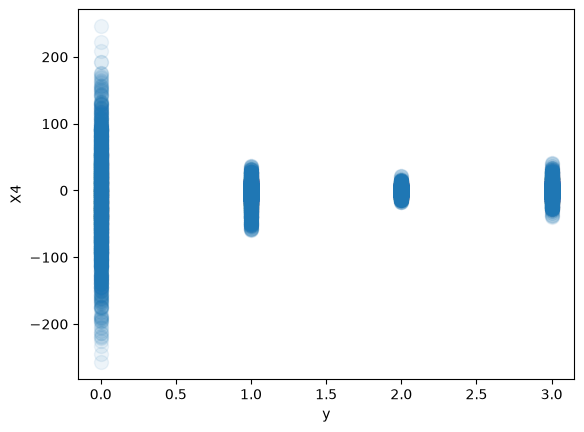

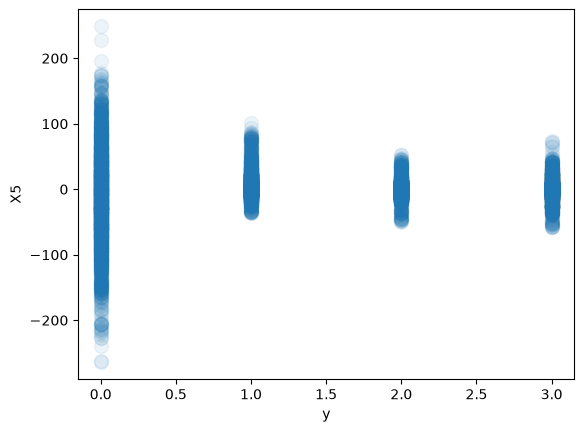

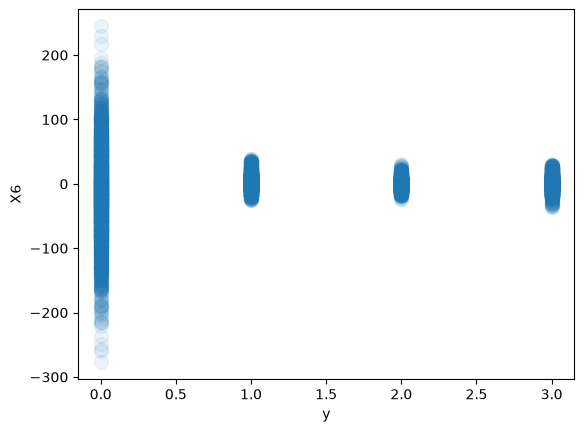

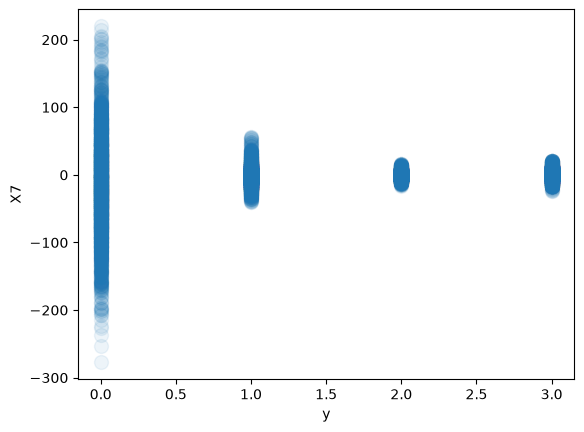

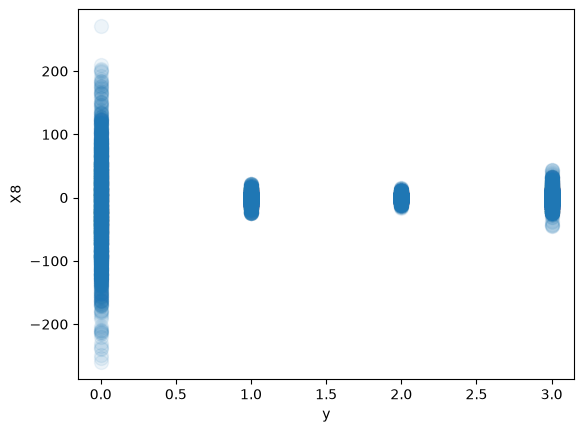

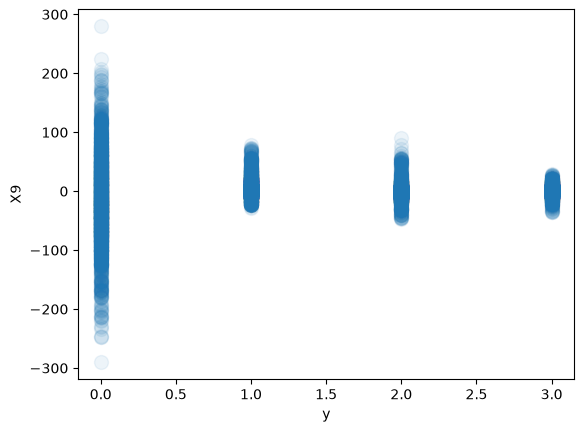

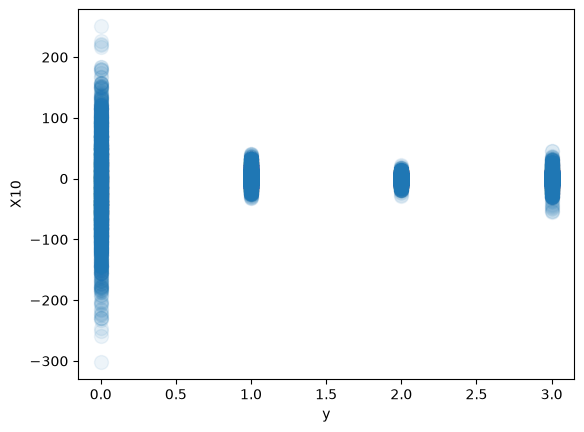

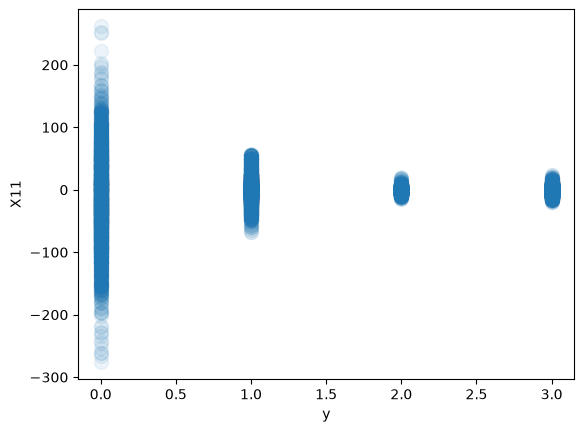

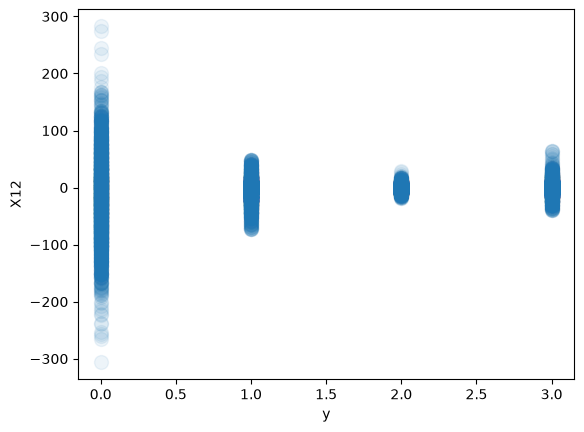

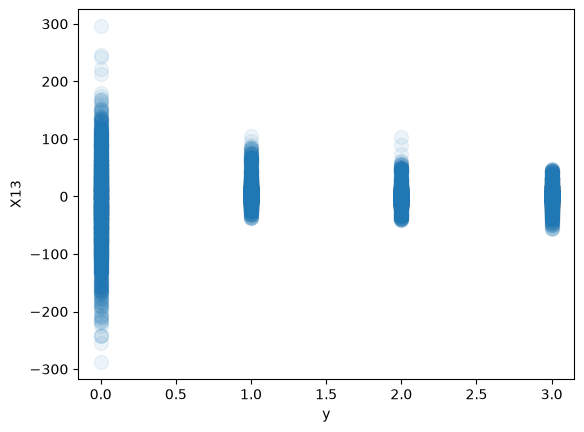

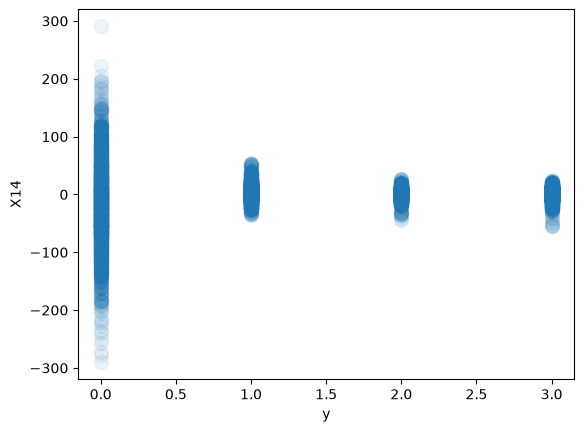

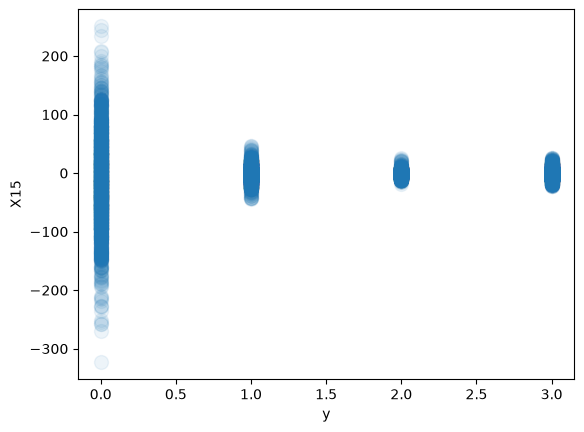

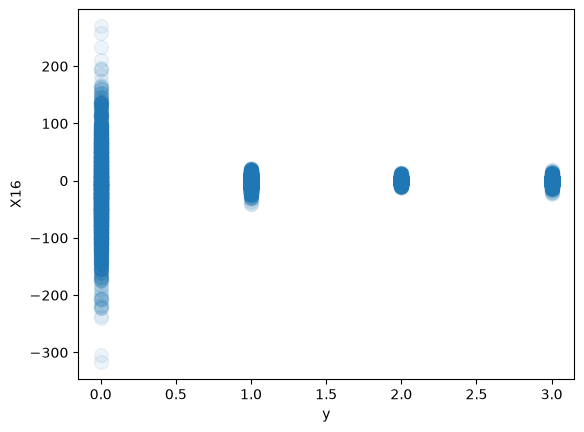

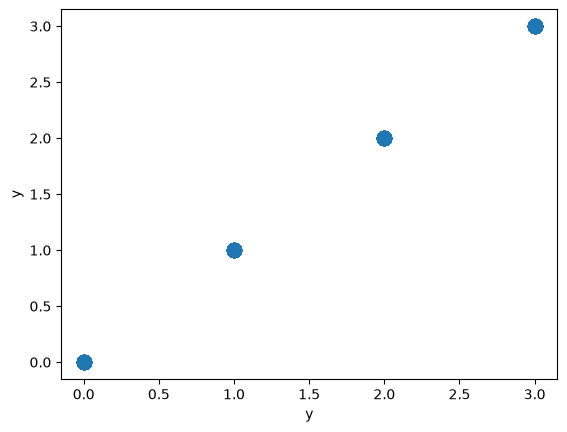

In [13]:
for col in data.columns:
   
    data.plot(kind = 'scatter', x = 'y',y = col,s = 100 ,alpha = 0.08)

    plt.show()


The value of Xn when y = 0 has high variance but for all other values of y, Xn has low variance

In [19]:
corr_matrix = data.corr()
corr_matrix['y'].sort_values(ascending=False)


y      1.000000
X16    0.143114
X15    0.137789
X12    0.137027
X4     0.124639
X14    0.120986
X11    0.118392
X8     0.115265
X7     0.114569
X13    0.113355
X10    0.110543
X3     0.109810
X6     0.107511
X2     0.102064
X9     0.099789
X1     0.098804
X5     0.091489
Name: y, dtype: float64

In [20]:
data["y"].value_counts()

y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64

The data is evenly disributed so no need for class weights or SMOTE

In [21]:
data.isnull().sum()

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
y      0
dtype: int64

In [22]:
X = data.drop("y", axis =1)
y = data["y"]

In [ ]:
model1 = LogisticRegression(max_iter=1200,class_weight="balanced")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [ ]:
scaler = StandardScaler()

# 4. Fit and transform the training data
# This calculates the mean and std dev, then applies the scaling formula
X_train_scaled = scaler.fit_transform(X_train)

# 5. Transform the testing data
# Crucial: Use .transform(), NOT .fit_transform() to prevent data leakage
X_test_scaled = scaler.transform(X_test)

In [ ]:
model1.fit(X_train_scaled,y_train)

In [ ]:
lr_pred = model1.predict(X_test_scaled)

In [ ]:
print(classification_report(y_test, lr_pred,target_names=[
        "Class 0",
        "Class 1",
        "Class 2",
        "Class 3"
    ]))

print("Accuracy:", accuracy_score(y_test, lr_pred))

confusion_matrix(y_test, lr_pred)

In [ ]:
rf_model = RandomForestClassifier(n_estimators=500,
        criterion='gini',
        max_depth=7,
        max_features='sqrt',
        random_state=1)

In [ ]:
rf_model.fit(X_train, y_train)

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
print(classification_report(y_test, rf_pred,target_names=[
        "Class 0",
        "Class 1",
        "Class 2",
        "Class 3"
    ]))

print("Accuracy:", accuracy_score(y_test, rf_pred))


confusion_matrix(y_test, rf_pred)

In [ ]:
param_grid = {
    'classifier__n_estimators': [875,887],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__max_depth' : [22,24,26,28,30,None],
    'classifier__criterion' :['gini', 'entropy']
}

cv_model = pipeline = Pipeline([
    ('classifier', RandomForestClassifier())
])

In [ ]:
random_search = RandomizedSearchCV(
    cv_model,
    param_grid,
    n_iter=30,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    random_state=0
)

random_search.fit(X_train, y_train)

In [ ]:
random_search_pred = random_search.predict(X_test_scaled)

In [ ]:
print(random_search.best_params_)

In [ ]:
print(classification_report(y_test, random_search_pred,target_names=[
        "Class 0",
        "Class 1",
        "Class 2",
        "Class 3"
    ]))

print("Accuracy:", accuracy_score(y_test, random_search_pred))


confusion_matrix(y_test, random_search_pred)

{'classifier__n_estimators': 800, 'classifier__max_features': 'log2', 'classifier__max_depth': 10, 'classifier__criterion': 'entropy'} : Accuracy: 0.82125

{'classifier__n_estimators': 850, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 12, 'classifier__criterion': 'gini'} : Accuracy: 0.853125

{'classifier__n_estimators': 875, 'classifier__max_features': 'log2', 'classifier__max_depth': 16, 'classifier__criterion': 'gini'} : Accuracy: 0.914375

{'classifier__n_estimators': 875, 'classifier__max_features': 'log2', 'classifier__max_depth': 24, 'classifier__criterion': 'gini'} : Accuracy: 0.9525

{'classifier__n_estimators': 875, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 26, 'classifier__criterion': 'entropy'} : Accuracy :0.954375

{'classifier__n_estimators': 887, 'classifier__max_features': 'log2', 'classifier__max_depth': None, 'classifier__criterion': 'entropy'} : Accuracy :0.965

In [ ]:
best_params = {
    'classifier__n_estimators': 887,
    'classifier__max_features': 'log2',
    'classifier__max_depth': None,
    'classifier__criterion': 'entropy'
}

In [ ]:
print("Training accuracy:", random_search.score(X_train, y_train))
print("Test accuracy:", random_search.score(X_test, y_test))

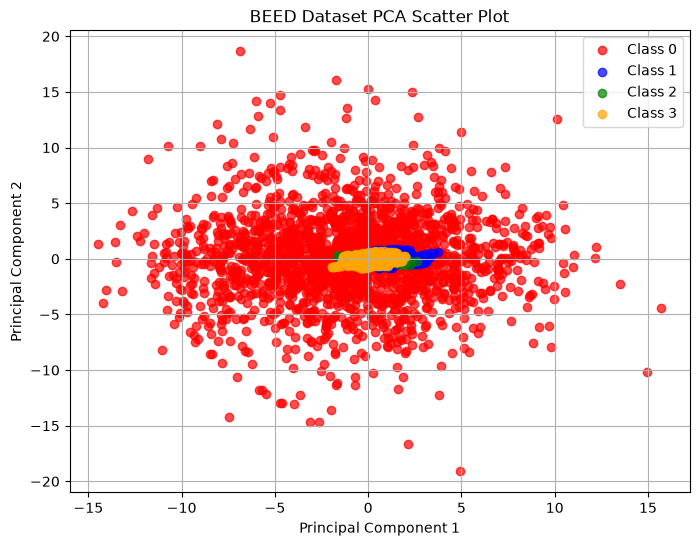

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green', 'orange']

for i in range(4):
    plt.scatter(
        X_pca[y == i, 0],
        X_pca[y == i, 1],
        label=f'Class {i}',
        color=colors[i],
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("BEED Dataset PCA Scatter Plot")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(classification_report(y_test, y_pred,target_names=[
        "Class 0",
        "Class 1",
        "Class 2",
        "Class 3"
    ]))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

neighbours = 5 : Accuracy: 0.95625
neighbours = 10 : Accuracy: 0.92375
neighbours = 6 : Accuracy: 0.95875 

In [ ]:
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=4))
])

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(classification_report(y_test, y_pred,target_names=[
        "Class 0",
        "Class 1",
        "Class 2",
        "Class 3"
    ]))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier())
])

param_grid = {
    "classifier__n_neighbors": [1,3,5,7,9,11,13,15],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy")

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

In [ ]:
y_pred = grid.predict(X_test)

print(classification_report(y_test, y_pred,target_names=[
        "Class 0",
        "Class 1",
        "Class 2",
        "Class 3"
    ]))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, random_search_pred),
        accuracy_score(y_test, y_pred)
    ]
})

results

KNN achieved the highest classification accuracy, suggesting that samples from the BEED dataset form well-separated clusters in the feature space.